# Align to a Reference Raster

This tutorial demonstrates how to align rasters to a reference raster, ensuring the same extent, resolution, and projection. This is a common task when comparing or combining multiple raster datasets.

```{figure} /_static/user_guide/examples/remote_sensing_alignment.png
   :alt: gallery_thumbnail
```

Aligning to a reference raster is straightforward. By passing the `res` (resolution) and `crs` (coordinate reference system) properties of the reference raster to the dataset being aligned during initialization, we can easily match the two. Next, sampling the dataset using the `bounds` of the reference raster ensures the data is aligned properly.

Here’s an example that aligns an amplitude product from an ALOS-2 image to a HyP3 image for comparison. The [RasterDataset](#faninsar.data.datasets.RasterDataset) class can be used to handle these standard raster datasets.

## Checking geospatial differences between two datasets

In [3]:
from faninsar.data import datasets
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

In [4]:
file_alos2 = "/Volumes/Data/Github/FanInSAR/tests/data/HyP3_ALOS2_Amplitude/ALOS2_phase.tif"
file_hyp3 = "/Volumes/Data/Github/FanInSAR/tests/data/HyP3_ALOS2_Amplitude/HyP3_Amplitude.tif"

In [5]:
ds_alos2 = datasets.RasterDataset(paths=[file_alos2])
ds_hyp3 = datasets.RasterDataset(paths=[file_hyp3])

In [6]:
arr_alos2  = ds_alos2[ds_alos2.bounds].boxes.data
arr_hyp3  = ds_hyp3[ds_hyp3.bounds].boxes.data

Loading  Files: 100%|██████████| 1/1 [00:00<00:00, 257.35 files/s]


We can see that the ALOS-2 image has a different resolution, CRS and extent than the HyP3 image.


In [7]:
print(
    f"ALOS2 Dataset:\n"
    f"  CRS: {ds_alos2.crs}\n"
    f"  Resolution: {ds_alos2.res}\n"
    f"  Shape: {arr_alos2[0].shape}\n"
    f"  Bounds: {ds_alos2.bounds}\n"
)
print(
    f"HyP3 Dataset:\n"
    f"  CRS: {ds_hyp3.crs}\n"
    f"  Resolution: {ds_hyp3.res}\n"
    f"  Shape: {arr_hyp3[0].shape}\n"
    f"  Bounds: {ds_hyp3.bounds}\n"
)

ALOS2 Dataset:
  CRS: EPSG:4326
  Resolution: (0.0008333333333333334, 0.0008333333333333334)
  Shape: (762, 829)
  Bounds: BoundingBox(left=98.6675, bottom=38.45666666666667, right=99.35833333333333, top=39.09166666666667, crs=EPSG:4326)

HyP3 Dataset:
  CRS: EPSG:32647
  Resolution: (40.0, 40.0)
  Shape: (147, 97)
  Bounds: BoundingBox(left=488290.56541342364, bottom=4293071.467859996, right=492170.56541342364, top=4298951.467859996, crs=EPSG:32647)



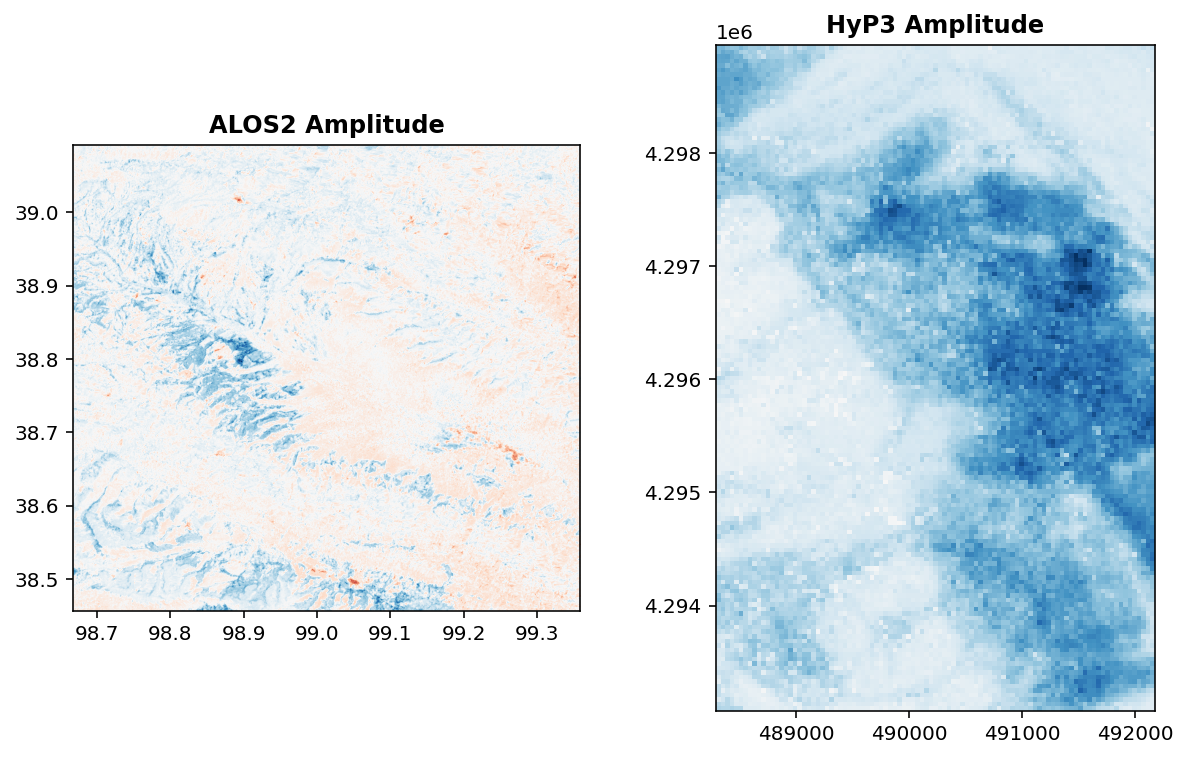

In [8]:
kwargs = dict(cmap="RdBu", vmin=-120, vmax=120)

fig, axs = plt.subplots(1, 2, figsize=(10, 6), dpi=144)

ds_alos2.show(arr_alos2, ax=axs[0], title="ALOS2 Amplitude", **kwargs)     
ds_hyp3.show(arr_hyp3, ax=axs[1], title="HyP3 Amplitude", **kwargs)

## Aligning ALOS2 to the Reference HyP3 Image


Aligning ALOS2 to a Reference Raster (HyP3) is straightforward: simply pass the `res` and `crs` properties from the HyP3 image to the ALOS2 dataset during initialization.

Additionally, we can specify the resampling algorithm for the alignment, which is defined in the `rasterio.enums.Resampling` enum, imported directly from `rasterio`. By default, the resampling method is set to `Resampling.nearest`, but alternatives such as `Resampling.bilinear` or `Resampling.cubic` can also be selected.

In [9]:
ds_alos2_aligned_nearest = datasets.RasterDataset(
    paths=[file_alos2],
    crs=ds_hyp3.crs,
    res=ds_hyp3.res,
)

ds_alos2_aligned_bilinear = datasets.RasterDataset(
    paths=[file_alos2],
    crs=ds_hyp3.crs,
    res=ds_hyp3.res,
    resampling=Resampling.bilinear,
)

In [10]:
arr_alos2_aligned_nearest = ds_alos2_aligned_nearest[ds_hyp3.bounds].boxes.data
arr_alos2_aligned_bilinear = ds_alos2_aligned_bilinear[ds_hyp3.bounds].boxes.data

Loading  Files: 100%|██████████| 1/1 [00:00<00:00, 93.44 files/s]


In [11]:
print(
    f"shape of HyP3: {arr_hyp3.shape}\n"
    f"shape of ALOS2 Aligned (Nearest): {arr_alos2_aligned_nearest.shape}\n"
    f"shape of ALOS2 Aligned (Bilinear): {arr_alos2_aligned_bilinear.shape}\n"
)

shape of HyP3: (1, 147, 97)
shape of ALOS2 Aligned (Nearest): (1, 147, 97)
shape of ALOS2 Aligned (Bilinear): (1, 147, 97)



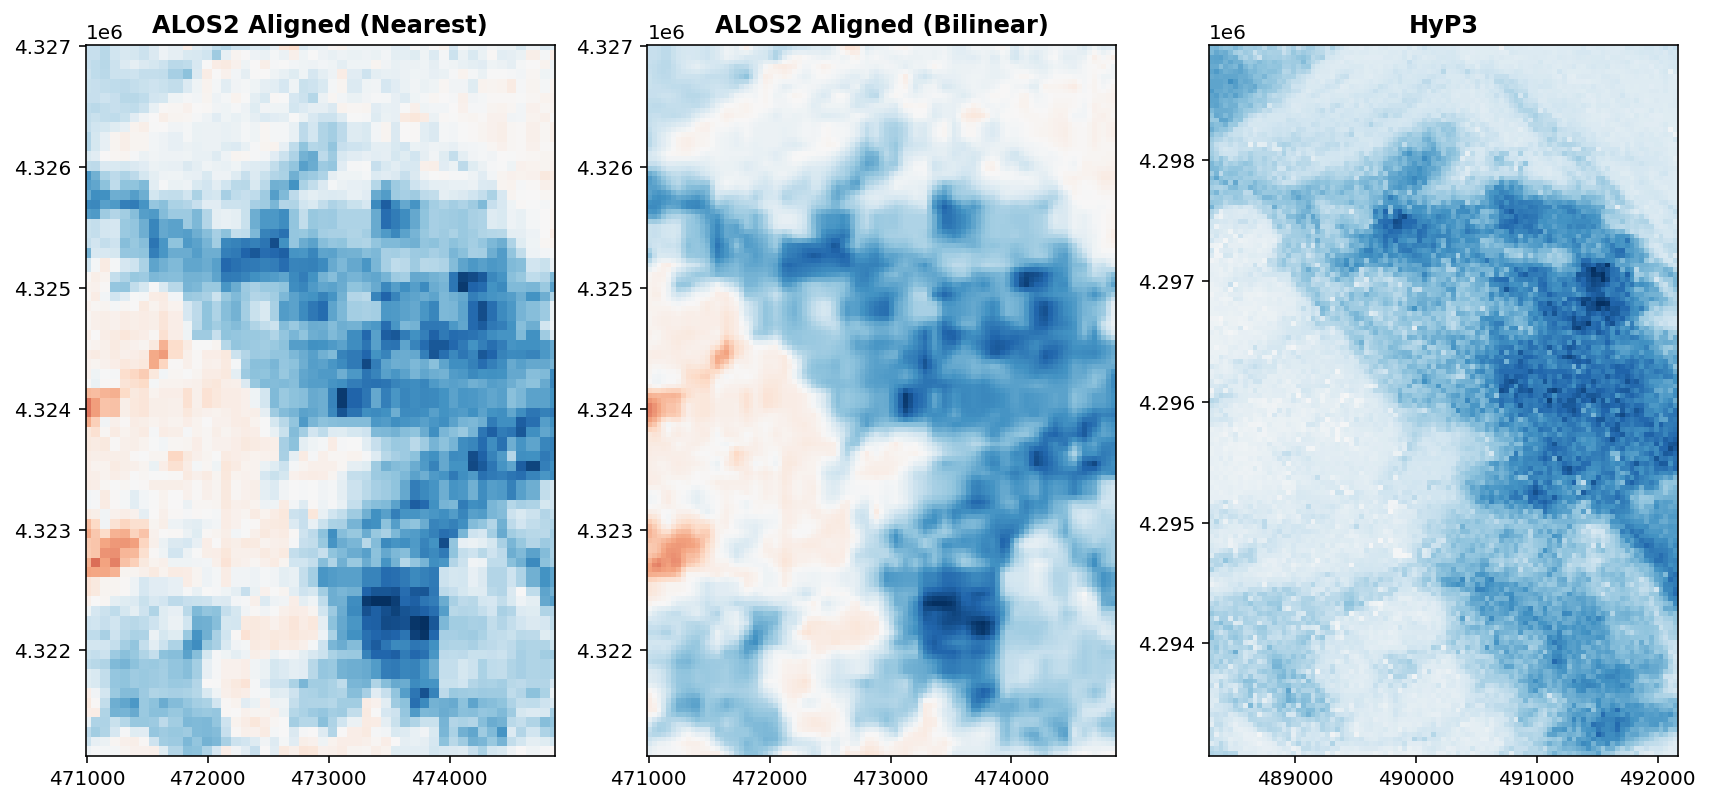

In [12]:
kwargs = dict(cmap="RdBu", vmin=-120, vmax=120)

fig, axs = plt.subplots(1, 3, figsize=(12, 6), dpi=144)

ds_alos2_aligned_nearest.show(arr_alos2_aligned_nearest, ax=axs[0], title="ALOS2 Aligned (Nearest)", **kwargs)
ds_alos2_aligned_bilinear.show(arr_alos2_aligned_bilinear, ax=axs[1], title="ALOS2 Aligned (Bilinear)", **kwargs)
ds_hyp3.show(arr_hyp3, ax=axs[2], title="HyP3", **kwargs)

plt.tight_layout()
plt.show()

Now, we can directly compare the aligned ALOS2 image with the HyP3 image. 

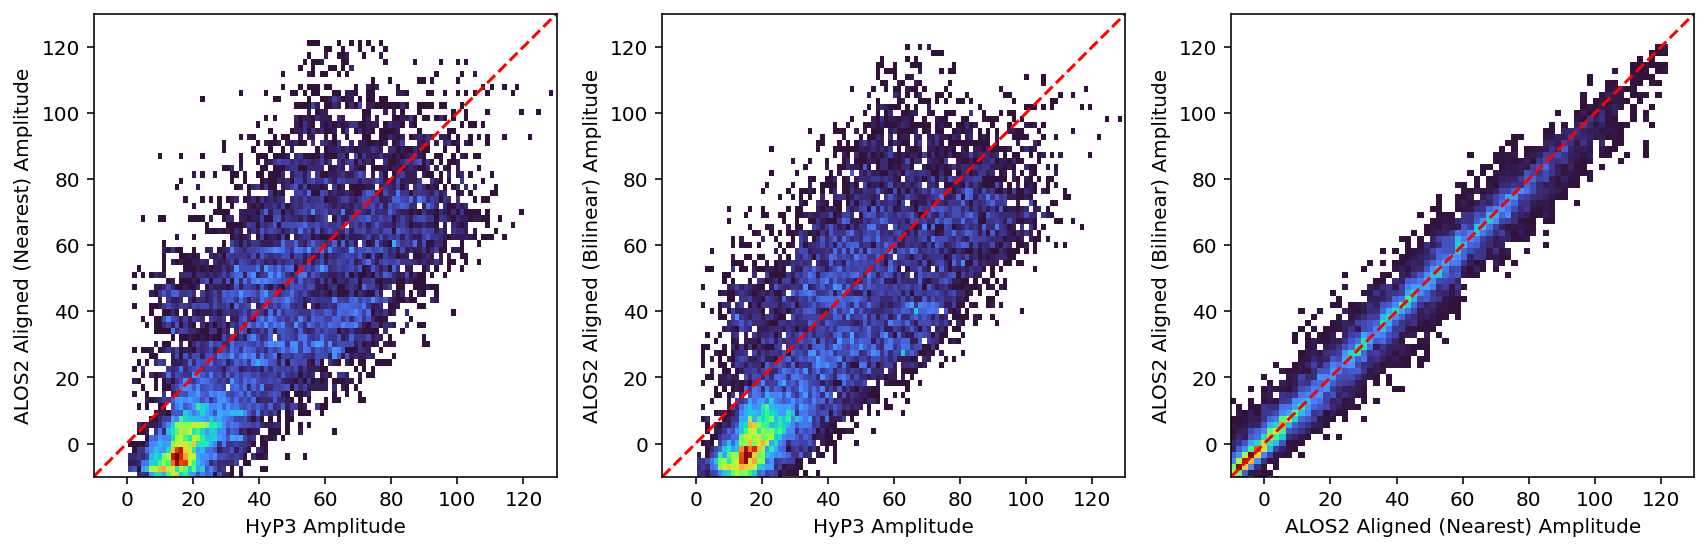

In [ ]:
rng = [-10, 130]

def plot_hist2d(ax, x, y, xlabel, ylabel):
    ax.hist2d(x.flatten(), y.flatten(), bins=100, cmap='turbo', cmin=1)
    ax.set_xlim(rng)
    ax.set_ylim(rng)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.plot(rng, rng, color="red", linestyle="--")
    ax.set_aspect("equal", adjustable="box")
    

fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=144)

plot_hist2d(axs[0], arr_hyp3, arr_alos2_aligned_nearest, "HyP3 Amplitude", "ALOS2 Aligned (Nearest) Amplitude")
plot_hist2d(axs[1], arr_hyp3, arr_alos2_aligned_bilinear, "HyP3 Amplitude", "ALOS2 Aligned (Bilinear) Amplitude")
plot_hist2d(axs[2], arr_alos2_aligned_nearest, arr_alos2_aligned_bilinear, "ALOS2 Aligned (Nearest) Amplitude", "ALOS2 Aligned (Bilinear) Amplitude")

plt.tight_layout()
plt.show()

## Save aligned ALOS2 images

In [13]:
file_alos2_aligned_nearest = "/Volumes/Data/temp/FanInSAR/ALOS2_phase_aligned.tif"
file_alos2_aligned_bilinear = "/Volumes/Data/temp/FanInSAR/ALOS2_phase_aligned_bilinear.tif"

ds_hyp3.array2tiff(arr_alos2_aligned_nearest, file_alos2_aligned_nearest)
ds_hyp3.array2tiff(arr_alos2_aligned_bilinear, file_alos2_aligned_bilinear)

## Verify saved aligned ALOS2 images

In [14]:
ds_alos2_aligned_nearest_new = datasets.RasterDataset(paths=[file_alos2_aligned_nearest])
ds_alos2_aligned_bilinear_new = datasets.RasterDataset(paths=[file_alos2_aligned_bilinear])

In [15]:
print(
    f"ALOS2 Aligned (Nearest) Dataset:\n"
    f"  CRS: {ds_alos2_aligned_nearest_new.crs}\n"
    f"  Resolution: {ds_alos2_aligned_nearest_new.res}\n"
    f"  Shape: {arr_alos2_aligned_nearest[0].shape}\n"
    f"  Bounds: {ds_alos2_aligned_nearest_new.bounds}\n"
)
print(
    f"ALOS2 Aligned (Bilinear) Dataset:\n"
    f"  CRS: {ds_alos2_aligned_bilinear_new.crs}\n"
    f"  Resolution: {ds_alos2_aligned_bilinear_new.res}\n"
    f"  Shape: {arr_alos2_aligned_bilinear[0].shape}\n"
    f"  Bounds: {ds_alos2_aligned_bilinear_new.bounds}\n"
)
print(
    f"HyP3 Dataset:\n"
    f"  CRS: {ds_hyp3.crs}\n"
    f"  Resolution: {ds_hyp3.res}\n"
    f"  Shape: {arr_hyp3[0].shape}\n"
    f"  Bounds: {ds_hyp3.bounds}\n"
)

ALOS2 Aligned (Nearest) Dataset:
  CRS: EPSG:32647
  Resolution: (40.0, 40.0)
  Shape: (147, 97)
  Bounds: BoundingBox(left=488290.56541342364, bottom=4293071.467859996, right=492170.56541342364, top=4298951.467859996, crs=EPSG:32647)

ALOS2 Aligned (Bilinear) Dataset:
  CRS: EPSG:32647
  Resolution: (40.0, 40.0)
  Shape: (147, 97)
  Bounds: BoundingBox(left=488290.56541342364, bottom=4293071.467859996, right=492170.56541342364, top=4298951.467859996, crs=EPSG:32647)

HyP3 Dataset:
  CRS: EPSG:32647
  Resolution: (40.0, 40.0)
  Shape: (147, 97)
  Bounds: BoundingBox(left=488290.56541342364, bottom=4293071.467859996, right=492170.56541342364, top=4298951.467859996, crs=EPSG:32647)

